# Joseph's Indicators — Visualizations (FIXED)
### Merges v7 + v8 + v9 — all bugs corrected

**Fixes applied:**
- Loads from CSV + re-runs spatial join → all 4 subareas populated (root-cause fix)
- Guards every chart/stats block with `len()` checks → no empty-array crashes
- CRS unified to `EPSG:3310` (metres) throughout
- Buffer distances in metres (402 / 805 / 1609), not feet
- `mannwhitneyu` skipped gracefully when comparison group is empty
- `posx/posy must be finite` fixed by checking `len` before `boxplot`/`text`

**Outputs:**
`map0_study_areas.png` · `map1_overview.png` · `map2_poe_distance_with_areas.png` · `map2b_poe_distance_circles.png` · `map3_otay_buffers.png` · `map4_kde_all_areas.png` · `chart_buffer_comparison.png` · `chart_poe_boxplot.png` · `chart_effect_sizes.png` · `stats_summary.csv`

**Run after** `joseph_indicators_v10.ipynb` has exported `joseph_indicators_output.csv` and `Community_Plan_SD.geojson` to the same directory.

## ⚙️ Configuration — Set Your File Paths Here

In [1]:
import os

# ── SET THESE TO MATCH YOUR ENVIRONMENT ───────────────────────────────────────
# Option A: files are in the same folder as this notebook → leave as "."
# Option B: paste the full path to the folder, e.g. "/home/user/joseph/" or
#           "C:/Users/you/Documents/joseph/"
DATA_DIR = "."   # ← change this if needed

# Derived paths (don't edit unless your filenames differ)
CSV_PATH            = os.path.join(DATA_DIR, "joseph_indicators_output.csv")
COMMUNITY_PLAN_PATH = os.path.join(DATA_DIR, "Community_Plan_SD.geojson")

# ── Quick sanity check ────────────────────────────────────────────────────────
for path, label in [(CSV_PATH, "CSV"), (COMMUNITY_PLAN_PATH, "GeoJSON")]:
    if os.path.exists(path):
        print(f"  ✓ {label} found: {os.path.abspath(path)}")
    else:
        print(f"  ✗ {label} NOT FOUND: {os.path.abspath(path)}")
        print(f"    → Update DATA_DIR above to the folder containing {os.path.basename(path)}")

  ✓ CSV found: /home/jhurr/private/Group_Project/joseph/joseph_indicators_output.csv
  ✓ GeoJSON found: /home/jhurr/private/Group_Project/joseph/Community_Plan_SD.geojson


## A. Setup

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from shapely.geometry import Point, box
import requests
from io import BytesIO
import warnings
warnings.filterwarnings("ignore")

# ── CRS ────────────────────────────────────────────────────────────────────────
CRS_GEO  = "EPSG:4326"
CRS_PROJ = "EPSG:3310"        # California Albers – metres
METERS_PER_MILE = 1609.34

# ── Study-area definitions ─────────────────────────────────────────────────────
STUDY_AREA_MAP = {
    "OTAY MESA":             "Otay Mesa",
    "OTAY MESA-NESTOR":      "Otay Mesa",
    "KEARNY MESA":           "Kearny Mesa",
    "MIRAMAR RANCH NORTH":   "Miramar",
    "SCRIPPS MIRAMAR RANCH": "Miramar",
    "MIRA MESA":             "Sorrento Valley",
}
STUDY_AREAS      = ["Otay Mesa", "Kearny Mesa", "Miramar", "Sorrento Valley"]
BORDER_AREA      = "Otay Mesa"
COMPARISON_AREAS = ["Kearny Mesa", "Miramar", "Sorrento Valley"]

AREA_COLORS = {
    "Otay Mesa":       "#e8522a",
    "Kearny Mesa":     "#2c7bb6",
    "Miramar":         "#1a9641",
    "Sorrento Valley": "#7b3294",
    "Other":           "#aaaaaa",
}

# 3-mile radius study circles (Canyu style, used in Map 0 / Map 2b)
AREA_CENTERS = {
    "Otay Mesa":       (-117.0548, 32.5751),
    "Kearny Mesa":     (-117.1397, 32.8264),
    "Miramar":         (-117.1050, 32.8970),
    "Sorrento Valley": (-117.2025, 32.8948),
}
AREA_RADIUS_M = 3.0 * METERS_PER_MILE   # 3-mile radius in metres

LABEL_OFFSETS_CIRCLE = {
    "Otay Mesa":       ( 18000, -12000),
    "Kearny Mesa":     (-30000,  10000),
    "Miramar":         ( 20000,  10000),
    "Sorrento Valley": (-44000,  10000),
}
LABEL_OFFSETS_POLY = {
    "Otay Mesa":       ( 25000, -12000),
    "Kearny Mesa":     (-35000,  12000),
    "Miramar":         ( 22000,  12000),
    "Sorrento Valley": (-48000,  12000),
}

BUFFER_DISTANCES_M = {
    "buffer_quarter_mi": 402,
    "buffer_half_mi":    805,
    "buffer_one_mi":    1609,
}
buf_labels = ["0.25 mi", "0.50 mi", "1.00 mi"]
buf_cols   = list(BUFFER_DISTANCES_M.keys())

## B. Load Data
**Root-cause fix:** previous versions loaded from `joseph_indicators_output.geojson`, which only retained Otay Mesa rows.  
This cell loads the CSV directly and re-runs the spatial join, giving all four subareas correct counts.

In [3]:
print("Loading CSV …")
df = pd.read_csv(CSV_PATH, dtype=str)
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
df = df.dropna(subset=["longitude", "latitude"]).reset_index(drop=True)

for col in ["dist_nearest_poe_mi", "dist_to_freight_road_mi",
            "buffer_quarter_mi", "buffer_half_mi", "buffer_one_mi"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs=CRS_GEO,
).to_crs(CRS_PROJ)

print(f"Loaded {len(gdf):,} businesses from CSV")

# ── Re-assign subarea via spatial join (fixes GeoJSON export bug) ─────────────
print("Loading community planning districts …")
planning = gpd.read_file(COMMUNITY_PLAN_PATH)
if planning.crs is None:
    planning = planning.set_crs(CRS_GEO)
planning = planning.to_crs(CRS_PROJ)

# FIX: if 'CPNAME' already exists in gdf (carried over from CSV), sjoin will
# create 'CPNAME_left' / 'CPNAME_right' suffixes and then gdf["CPNAME"] fails.
# Drop any pre-existing CPNAME before the join so we always get a clean column.
gdf = gdf.drop(columns=["CPNAME"], errors="ignore")

gdf = gpd.sjoin(
    gdf,
    planning[["CPNAME", "geometry"]],
    how="left", predicate="within",
).drop(columns=["index_right"], errors="ignore")
gdf = gdf[~gdf.index.duplicated(keep="first")]

# After sjoin, the column might be 'CPNAME_right' if a suffix was added anyway
if "CPNAME" not in gdf.columns:
    for col in gdf.columns:
        if col.startswith("CPNAME"):
            gdf = gdf.rename(columns={col: "CPNAME"})
            break

gdf["CPNAME"]  = gdf["CPNAME"].fillna("Outside City Planning Areas")
gdf["subarea"] = gdf["CPNAME"].map(STUDY_AREA_MAP).fillna("Other")

print("\nSubarea counts:")
print(gdf["subarea"].value_counts().to_string())

subarea_gdfs = {a: gdf[gdf["subarea"] == a].copy() for a in STUDY_AREAS}
subarea_gdfs["Other"] = gdf[gdf["subarea"] == "Other"].copy()
otay   = subarea_gdfs["Otay Mesa"]
nonbdr = gdf[gdf["subarea"] != "Otay Mesa"]

# ── POE fallback ───────────────────────────────────────────────────────────────
poe_raw = gpd.GeoDataFrame(
    {"name": ["San Ysidro POE", "Otay Mesa POE"]},
    geometry=[Point(-117.0295, 32.5440), Point(-116.9447, 32.5726)],
    crs=CRS_GEO,
).to_crs(CRS_PROJ)

# ── Buffer overlap summary ─────────────────────────────────────────────────────
def pct_inside(sub, col):
    if len(sub) == 0 or col not in sub.columns: return 0.0
    return round(100 * sub[col].mean(), 1)

buf_pcts = {a: [pct_inside(subarea_gdfs[a], c) for c in buf_cols] for a in STUDY_AREAS}

print("\nBuffer overlap summary:")
for a in STUDY_AREAS:
    print(f"  {a}: {buf_pcts[a]}")

Loading CSV …
Loaded 2,500 businesses from CSV
Loading community planning districts …

Subarea counts:
subarea
Other              1380
Otay Mesa           493
Sorrento Valley     369
Kearny Mesa         206
Miramar              52

Buffer overlap summary:
  Otay Mesa: [nan, nan, nan]
  Kearny Mesa: [nan, nan, nan]
  Miramar: [nan, nan, nan]
  Sorrento Valley: [nan, nan, nan]


## C. Fetch SANDAG Reference Layers

In [4]:
print("Fetching SANDAG major roads …")
try:
    major_roads = gpd.read_file(BytesIO(requests.get(
        "https://gis.sandag.org/FreightViewer/data/MajorRoads_20171002.json",
        timeout=60).content)).to_crs(CRS_PROJ)
    roads_dissolved = major_roads.dissolve().geometry.iloc[0]
    print(f"  {len(major_roads)} features loaded")
except Exception as e:
    print(f"  [fallback] {e}")
    major_roads = None
    roads_dissolved = None

# ── Study-area polygon outlines from planning districts ───────────────────────
study_area_polys = {}
for cpname, label in STUDY_AREA_MAP.items():
    rows = planning[planning["CPNAME"].str.upper() == cpname.upper()]
    if len(rows):
        poly = rows.geometry.unary_union
        study_area_polys[label] = (
            study_area_polys[label].union(poly)
            if label in study_area_polys else poly)

# ── 3-mile study circles (Canyu style) ────────────────────────────────────────
circle_geoms = {}
for name, (lon, lat) in AREA_CENTERS.items():
    pt = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs=CRS_GEO).to_crs(CRS_PROJ)
    circle_geoms[name] = pt.geometry.iloc[0].buffer(AREA_RADIUS_M)

minx, miny, maxx, maxy = planning.total_bounds
margin = 5000

print("\nSetup complete.")

Fetching SANDAG major roads …
  45 features loaded

Setup complete.


## D. Helper Functions

In [5]:
def add_study_outlines(ax, zorder_base=3, offsets=None):
    """Draw planning-district polygon outlines + labelled arrows."""
    if offsets is None: offsets = LABEL_OFFSETS_POLY
    for area, poly in study_area_polys.items():
        col = AREA_COLORS[area]
        gp  = gpd.GeoDataFrame(geometry=[poly], crs=CRS_PROJ)
        gp.plot(ax=ax, color=col, alpha=0.10, zorder=zorder_base)
        gp.boundary.plot(ax=ax, color=col, linewidth=2.0,
                         linestyle="--", zorder=zorder_base + 1)
        cx, cy = poly.centroid.x, poly.centroid.y
        dx, dy = offsets.get(area, (0, 0))
        tag = "border" if area == BORDER_AREA else "comparison"
        ax.annotate(f"{area}\n({tag})",
                    xy=(cx, cy), xytext=(cx + dx, cy + dy),
                    fontsize=9, fontweight="bold", color=col,
                    ha="center", va="center",
                    arrowprops=dict(arrowstyle="-", color=col, lw=1.2),
                    bbox=dict(boxstyle="round,pad=0.28", fc="white",
                              ec=col, lw=1.3, alpha=0.94),
                    zorder=zorder_base + 2)


def add_study_circles(ax, zorder_base=5):
    """Draw 3-mile radius circles + labels (Canyu style)."""
    for name, circle in circle_geoms.items():
        col = AREA_COLORS[name]
        cgdf = gpd.GeoDataFrame(geometry=[circle], crs=CRS_PROJ)
        cgdf.plot(ax=ax, color=col, alpha=0.07, zorder=zorder_base)
        cgdf.boundary.plot(ax=ax, color=col, linewidth=2.0,
                           linestyle="--", zorder=zorder_base + 1)
        cx, cy = circle.centroid.x, circle.centroid.y
        dx, dy = LABEL_OFFSETS_CIRCLE.get(name, (0, 0))
        tag = "border" if name == BORDER_AREA else "comparison"
        ax.annotate(f"{name}\n({tag})",
                    xy=(cx, cy), xytext=(cx + dx, cy + dy),
                    fontsize=9, fontweight="bold", color=col,
                    ha="center", va="center",
                    arrowprops=dict(arrowstyle="-", color=col, lw=1.2),
                    bbox=dict(boxstyle="round,pad=0.28", fc="white",
                              ec=col, lw=1.3, alpha=0.94),
                    zorder=zorder_base + 2)

## Map 0 — Study Area Reference (no business points)
Standalone orientation figure for StoryMap.

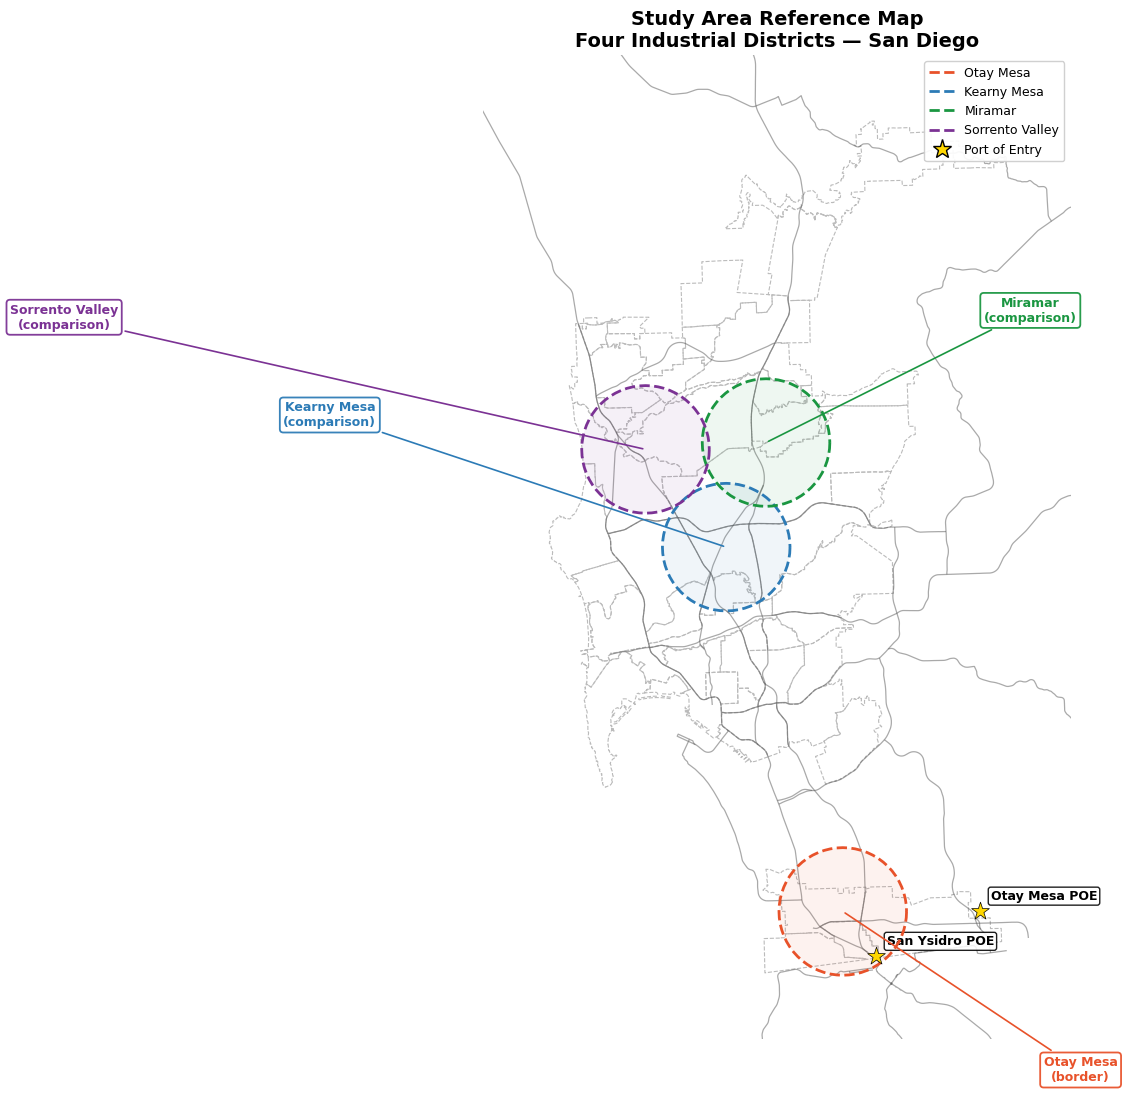

Saved: map0_study_areas.png


In [6]:
fig, ax = plt.subplots(figsize=(13, 11))
planning.plot(ax=ax, color="none", edgecolor="#bbb", linewidth=0.8,
              linestyle="--", zorder=0)
if major_roads is not None:
    major_roads.plot(ax=ax, color="#555", linewidth=0.9, alpha=0.5, zorder=1)
add_study_circles(ax, zorder_base=3)
poe_raw.plot(ax=ax, color="gold", markersize=180, marker="*",
             zorder=7, edgecolor="black", linewidth=0.5)
for _, row in poe_raw.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(8, 8), textcoords="offset points",
                fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.88))
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
legend_els = [
    Line2D([0], [0], color=AREA_COLORS[a], linewidth=2, linestyle="--", label=a)
    for a in STUDY_AREAS
] + [Line2D([0], [0], marker="*", color="w", markerfacecolor="gold",
            markersize=14, markeredgecolor="black", label="Port of Entry")]
ax.legend(handles=legend_els, loc="upper right", fontsize=9, framealpha=0.92)
ax.set_title("Study Area Reference Map\nFour Industrial Districts — San Diego",
             fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("map0_study_areas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map0_study_areas.png")

## Map 1 — Overview: All Industrial Businesses by Subarea

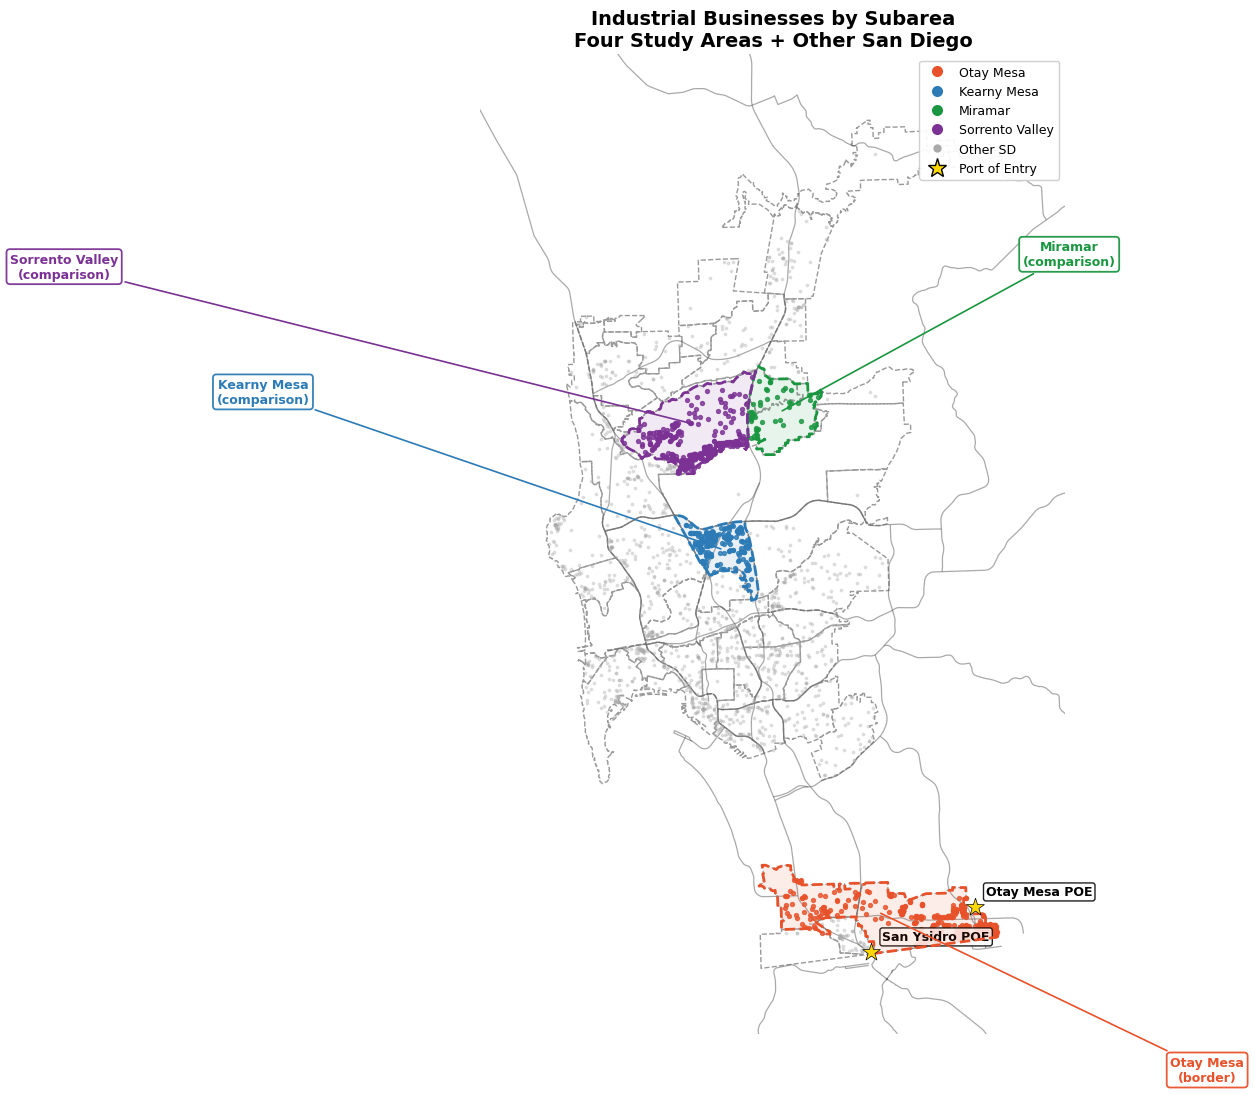

Saved: map1_overview.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 11))
planning.plot(ax=ax, color="none", edgecolor="#999", linewidth=1.0,
              linestyle="--", zorder=0)
if major_roads is not None:
    major_roads.plot(ax=ax, color="#555", linewidth=0.9, alpha=0.5, zorder=1)
subarea_gdfs["Other"].plot(ax=ax, color=AREA_COLORS["Other"],
                           markersize=3, alpha=0.3, zorder=2)
for area in STUDY_AREAS:
    subarea_gdfs[area].plot(ax=ax, color=AREA_COLORS[area],
                            markersize=8, alpha=0.8, zorder=3, label=area)
add_study_outlines(ax, zorder_base=4)
poe_raw.plot(ax=ax, color="gold", markersize=180, marker="*",
             zorder=7, edgecolor="black", linewidth=0.5, label="Port of Entry")
for _, row in poe_raw.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(8, 8), textcoords="offset points", fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.88))
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
legend_els = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=AREA_COLORS[a],
           markersize=9, label=a) for a in STUDY_AREAS
] + [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=AREA_COLORS["Other"],
           markersize=7, label="Other SD"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gold",
           markersize=14, markeredgecolor="black", label="Port of Entry"),
]
ax.legend(handles=legend_els, loc="upper right", fontsize=9, framealpha=0.92)
ax.set_title("Industrial Businesses by Subarea\nFour Study Areas + Other San Diego",
             fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("map1_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map1_overview.png")

## Map 2 — Distance to Nearest POE (Graduated Colour)
Green = close to a port, Red = far. Capped at 30 miles so the colour scale is meaningful for the study area.

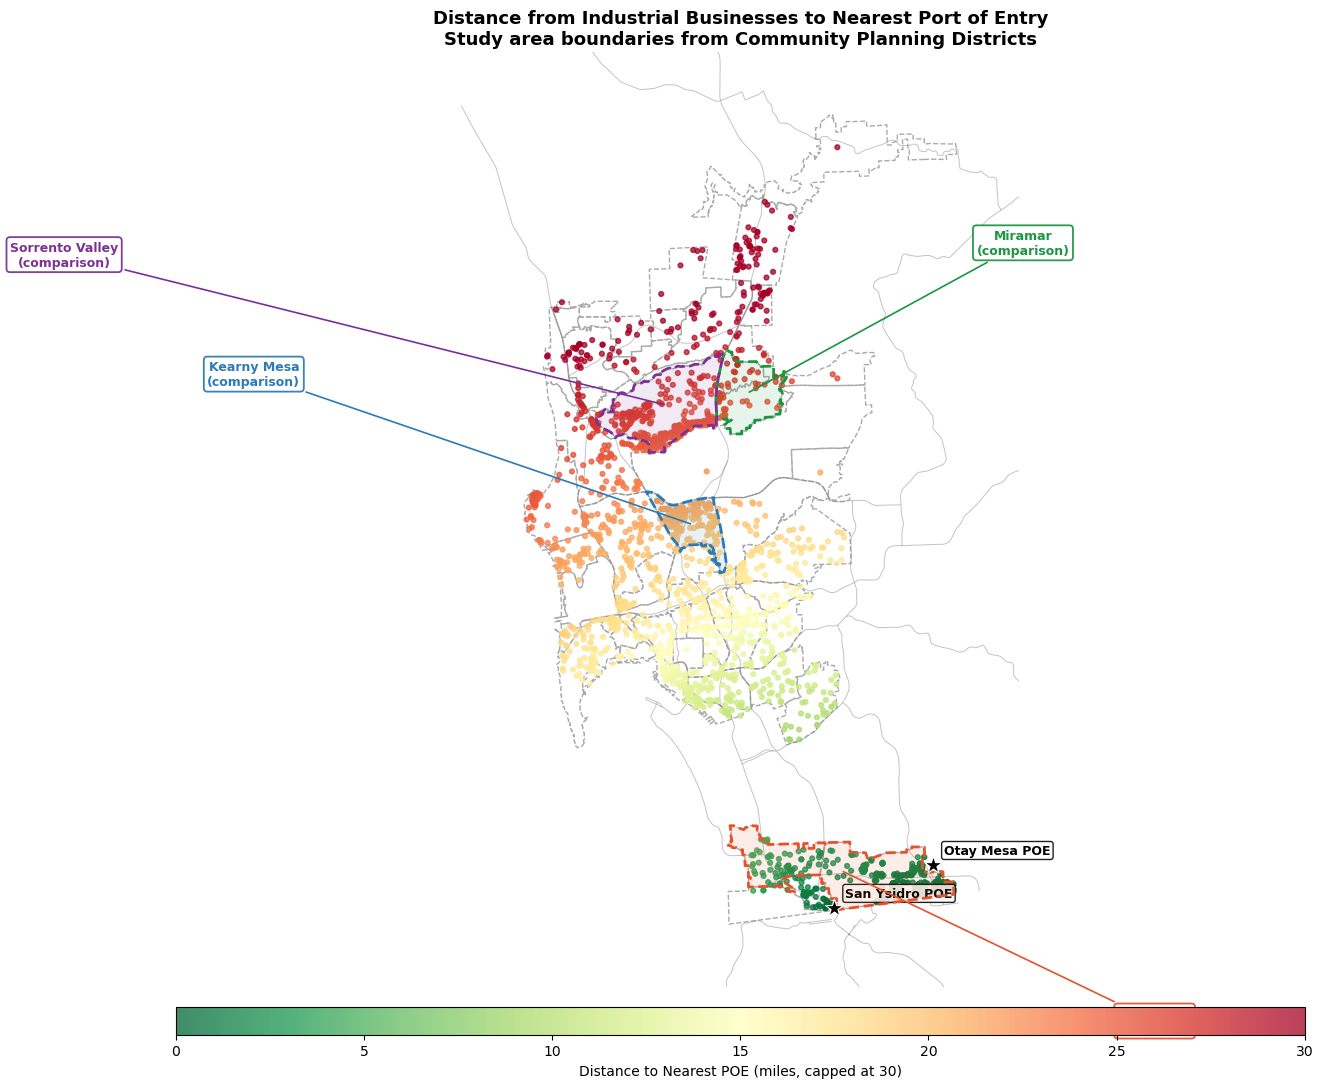

Saved: map2_poe_distance_with_areas.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 11))
planning.plot(ax=ax, color="none", edgecolor="#aaa", linewidth=1.0,
              linestyle="--", zorder=0)
if major_roads is not None:
    major_roads.plot(ax=ax, color="#888", linewidth=0.7, alpha=0.5, zorder=1)
if "dist_nearest_poe_mi" in gdf.columns:
    gdf["dist_capped"] = gdf["dist_nearest_poe_mi"].clip(upper=30)
    sc = ax.scatter(gdf.geometry.x, gdf.geometry.y,
                    c=gdf["dist_capped"], cmap="RdYlGn_r",
                    s=12, alpha=0.75, zorder=3, vmin=0, vmax=30)
    cb = plt.colorbar(sc, ax=ax, orientation="horizontal",
                      pad=0.02, fraction=0.03, aspect=40)
    cb.set_label("Distance to Nearest POE (miles, capped at 30)", fontsize=10)
add_study_outlines(ax, zorder_base=4)
poe_raw.plot(ax=ax, color="black", markersize=180, marker="*",
             zorder=7, edgecolor="white", linewidth=0.8)
for _, row in poe_raw.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(8, 8), textcoords="offset points", fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.88))
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
ax.set_title("Distance from Industrial Businesses to Nearest Port of Entry\n"
             "Study area boundaries from Community Planning Districts",
             fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("map2_poe_distance_with_areas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map2_poe_distance_with_areas.png")

## Map 2b — POE Distance + 3-Mile Study Area Circles (Canyu style)
Same graduated-colour map with Canyu's 3-mile radius windows overlaid so readers can immediately see which cluster is which.

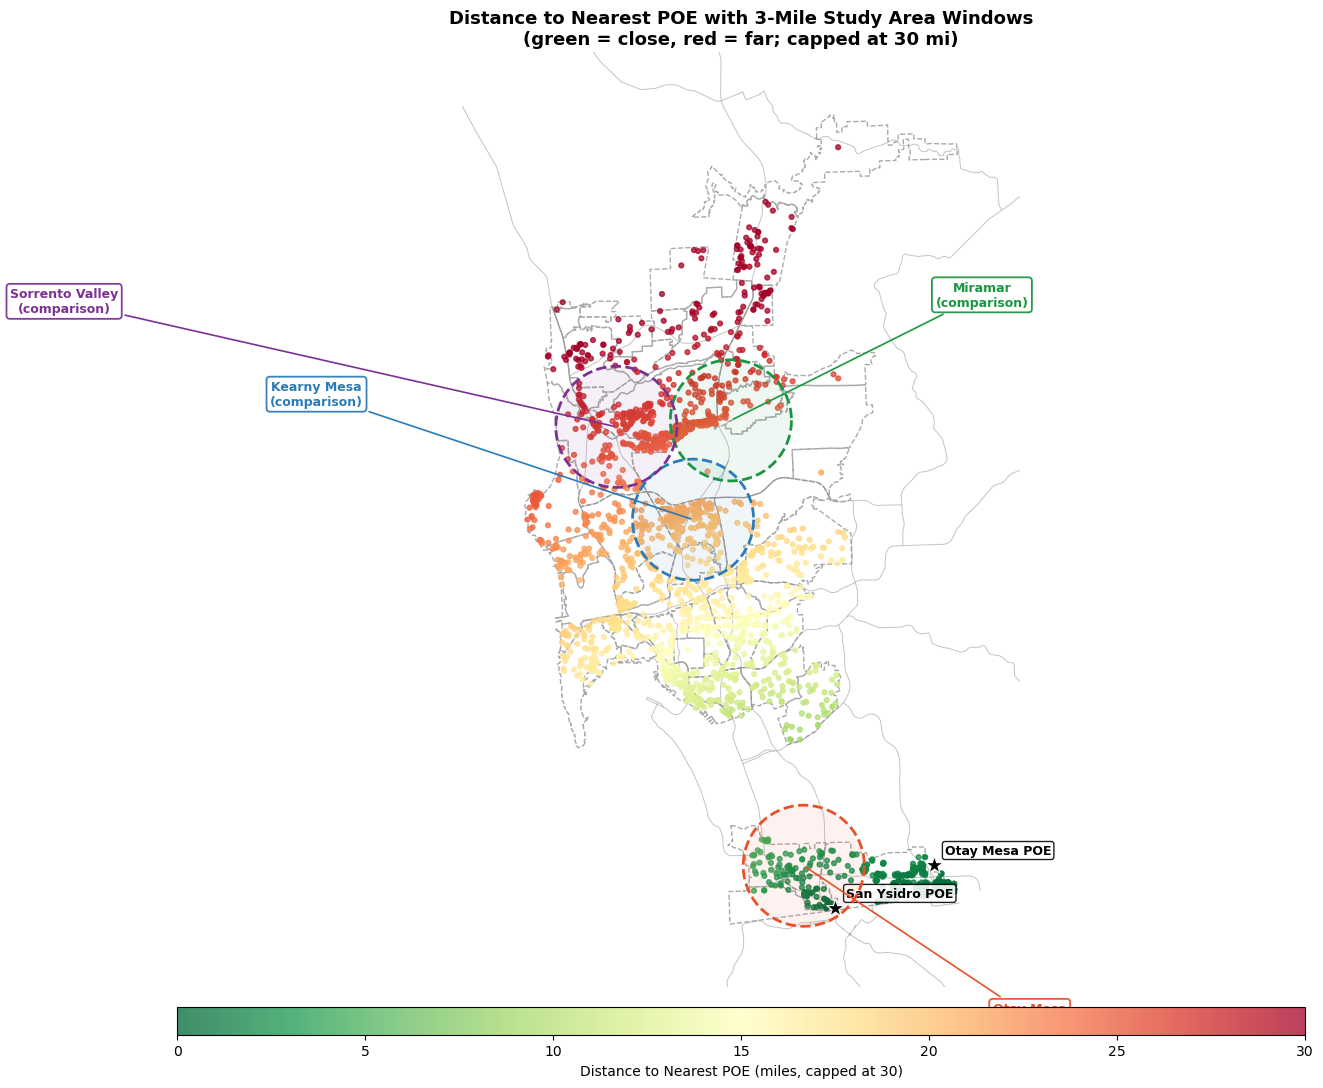

Saved: map2b_poe_distance_circles.png


In [9]:
fig, ax = plt.subplots(figsize=(13, 11))
planning.plot(ax=ax, color="none", edgecolor="#aaa", linewidth=1.0,
              linestyle="--", zorder=0)
if major_roads is not None:
    major_roads.plot(ax=ax, color="#888", linewidth=0.7, alpha=0.5, zorder=1)
if "dist_nearest_poe_mi" in gdf.columns:
    gdf["dist_capped"] = gdf["dist_nearest_poe_mi"].clip(upper=30)
    sc = ax.scatter(gdf.geometry.x, gdf.geometry.y,
                    c=gdf["dist_capped"], cmap="RdYlGn_r",
                    s=12, alpha=0.75, zorder=3, vmin=0, vmax=30)
    cb = plt.colorbar(sc, ax=ax, orientation="horizontal",
                      pad=0.02, fraction=0.03, aspect=40)
    cb.set_label("Distance to Nearest POE (miles, capped at 30)", fontsize=10)
add_study_circles(ax, zorder_base=5)
poe_raw.plot(ax=ax, color="black", markersize=180, marker="*",
             zorder=8, edgecolor="white", linewidth=0.8)
for _, row in poe_raw.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(8, 8), textcoords="offset points", fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.88))
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
ax.set_title("Distance to Nearest POE with 3-Mile Study Area Windows\n"
             "(green = close, red = far; capped at 30 mi)",
             fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("map2b_poe_distance_circles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map2b_poe_distance_circles.png")

## Map 3 — Otay Mesa Zoom: Freight Corridor Buffer Rings
Zoomed into Otay Mesa showing 0.25 / 0.50 / 1.00-mile buffer rings. This is the strongest visual for Indicator 2.

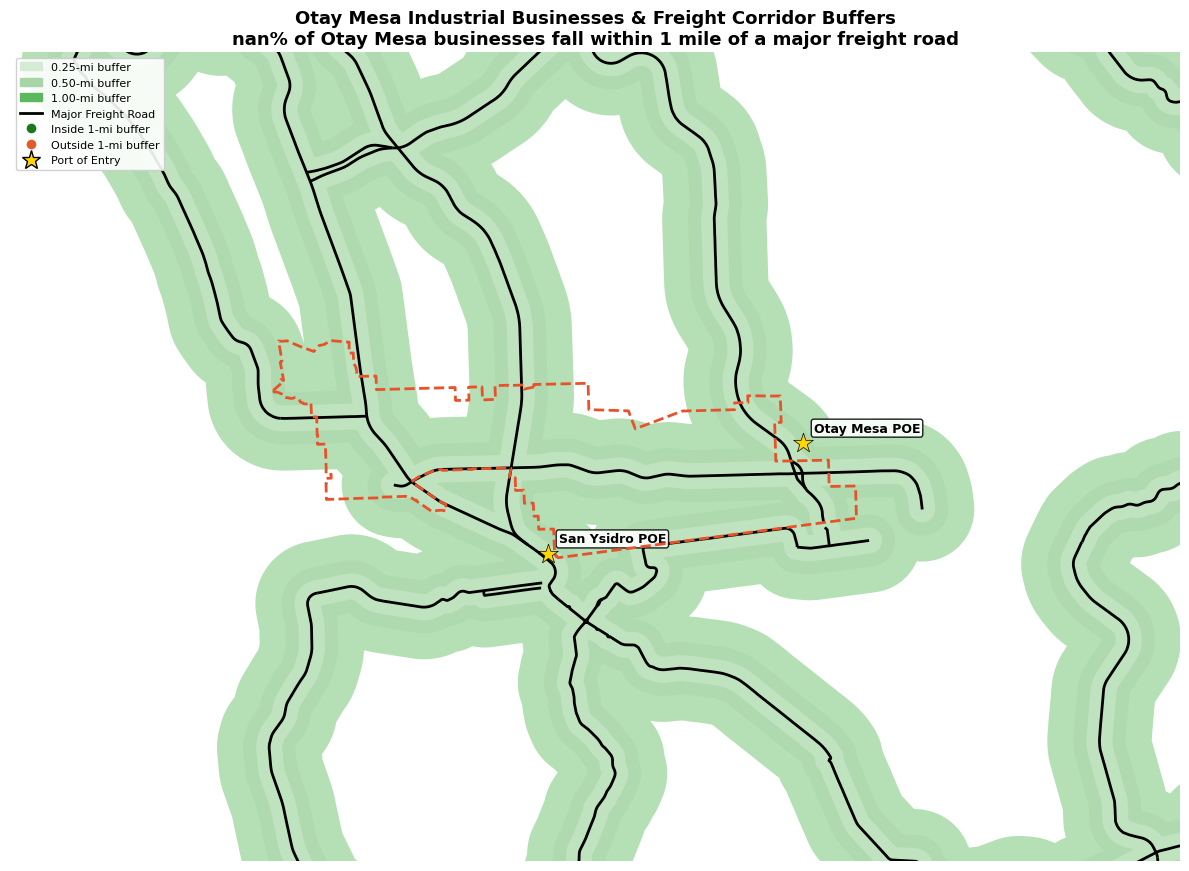

Saved: map3_otay_buffers.png


In [10]:
if roads_dissolved is not None and len(otay):
    buffers = {f"{v / METERS_PER_MILE:.2f} mi": roads_dissolved.buffer(v)
               for v in BUFFER_DISTANCES_M.values()}
    ob = otay.total_bounds; bm = 10000
    xlim = (ob[0] - bm, ob[2] + bm)
    ylim = (ob[1] - bm, ob[3] + bm)
    pct1mi = (round(100 * otay["buffer_one_mi"].mean(), 1)
              if "buffer_one_mi" in otay.columns else "N/A")

    fig, ax = plt.subplots(figsize=(12, 10))
    buf_colors = ["#d4ecd4", "#a8d5a8", "#5cb85c"]
    for (lbl, buf), col in zip(reversed(list(buffers.items())), reversed(buf_colors)):
        gpd.GeoDataFrame(geometry=[buf], crs=CRS_PROJ).plot(
            ax=ax, color=col, alpha=0.45, zorder=1)
    if major_roads is not None:
        major_roads.plot(ax=ax, color="black", linewidth=2.0, zorder=3,
                         label="Major Freight Road")
    if "buffer_one_mi" in otay.columns:
        inside  = otay[otay["buffer_one_mi"] == 1]
        outside = otay[otay["buffer_one_mi"] == 0]
        inside.plot(ax=ax, color="#1a7a1a", markersize=18, alpha=0.85,
                    zorder=4, label="Inside 1-mi buffer")
        outside.plot(ax=ax, color="#e05c2a", markersize=18, alpha=0.85,
                     zorder=4, label="Outside 1-mi buffer")
    else:
        otay.plot(ax=ax, color="#1a7a1a", markersize=18, alpha=0.85, zorder=4)
    poe_raw.plot(ax=ax, color="gold", markersize=220, marker="*",
                 zorder=6, edgecolor="black", linewidth=0.5, label="Port of Entry")
    for _, row in poe_raw.iterrows():
        ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                    xytext=(8, 8), textcoords="offset points", fontsize=9,
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.88))
    if "Otay Mesa" in study_area_polys:
        gpd.GeoDataFrame(geometry=[study_area_polys["Otay Mesa"]],
                         crs=CRS_PROJ).boundary.plot(
            ax=ax, color=AREA_COLORS["Otay Mesa"], linewidth=2.0,
            linestyle="--", zorder=5, label="Otay Mesa boundary")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    buf_patches = [mpatches.Patch(color=c, label=f"{l} buffer")
                   for c, l in zip(buf_colors, ["0.25-mi", "0.50-mi", "1.00-mi"])]
    ax.legend(handles=buf_patches + [
        Line2D([0], [0], color="black", linewidth=2, label="Major Freight Road"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#1a7a1a",
               markersize=8, label="Inside 1-mi buffer"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#e05c2a",
               markersize=8, label="Outside 1-mi buffer"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="gold",
               markersize=14, markeredgecolor="black", label="Port of Entry"),
    ], loc="upper left", fontsize=8, framealpha=0.9)
    ax.set_title(f"Otay Mesa Industrial Businesses & Freight Corridor Buffers\n"
                 f"{pct1mi}% of Otay Mesa businesses fall within 1 mile of a major freight road",
                 fontsize=13, fontweight="bold")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig("map3_otay_buffers.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: map3_otay_buffers.png")
else:
    print("Skipping Map 3 – roads or Otay Mesa data unavailable.")

## Map 4 — Kernel Density Estimate: All Four Study Areas
2×2 grid comparing spatial clustering intensity across all study areas.

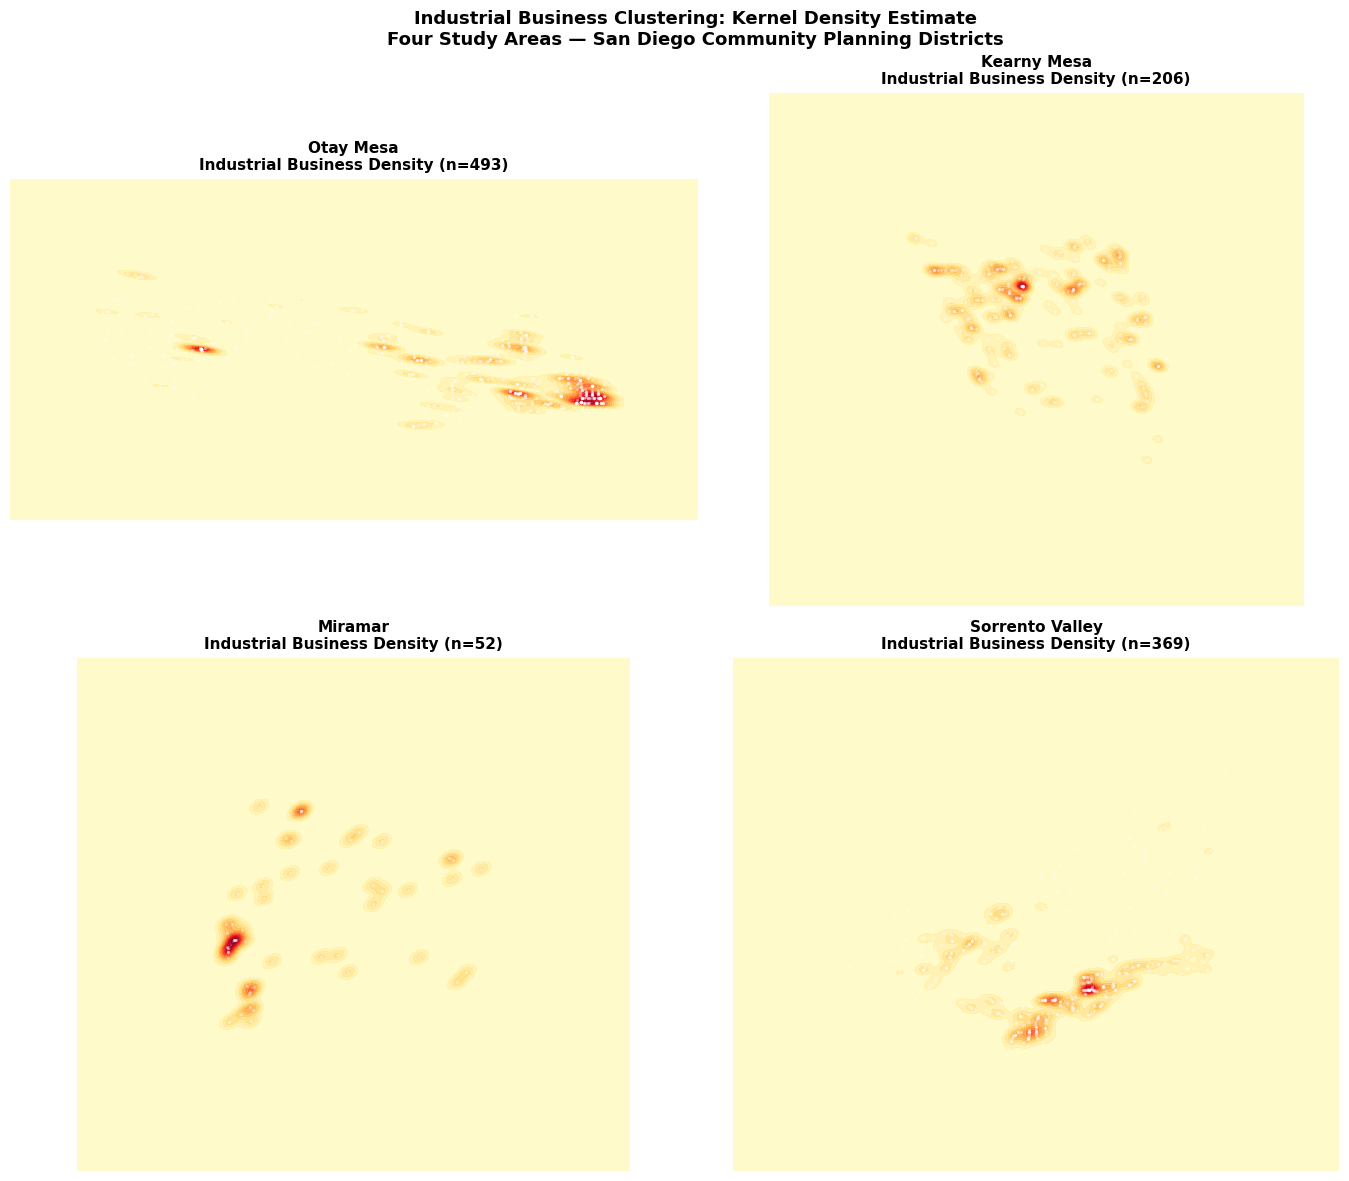

Saved: map4_kde_all_areas.png


In [11]:
try:
    from scipy.stats import gaussian_kde

    def kde_heatmap(ax, pts, title, xlim=None, ylim=None, cmap="YlOrRd"):
        coords = np.array([[g.x, g.y] for g in pts.geometry])
        if len(coords) < 5:
            ax.set_title(title); return
        kde = gaussian_kde(coords.T, bw_method=0.08)
        if xlim is None: xlim = (coords[:, 0].min() - 3000, coords[:, 0].max() + 3000)
        if ylim is None: ylim = (coords[:, 1].min() - 3000, coords[:, 1].max() + 3000)
        xx, yy = np.mgrid[xlim[0]:xlim[1]:200j, ylim[0]:ylim[1]:200j]
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=15, cmap=cmap, alpha=0.85)
        pts.plot(ax=ax, color="white", markersize=2, alpha=0.3, zorder=2)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_axis_off()

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle("Industrial Business Clustering: Kernel Density Estimate\n"
                 "Four Study Areas — San Diego Community Planning Districts",
                 fontsize=13, fontweight="bold")
    for i, area in enumerate(STUDY_AREAS):
        sub = subarea_gdfs[area]
        kde_heatmap(axes.flat[i], sub,
                    f"{area}\nIndustrial Business Density (n={len(sub):,})")
    plt.tight_layout()
    plt.savefig("map4_kde_all_areas.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: map4_kde_all_areas.png")
except ImportError:
    print("scipy not available – skipping KDE map.")

## Chart — Buffer Overlap Comparison (Four Areas)

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

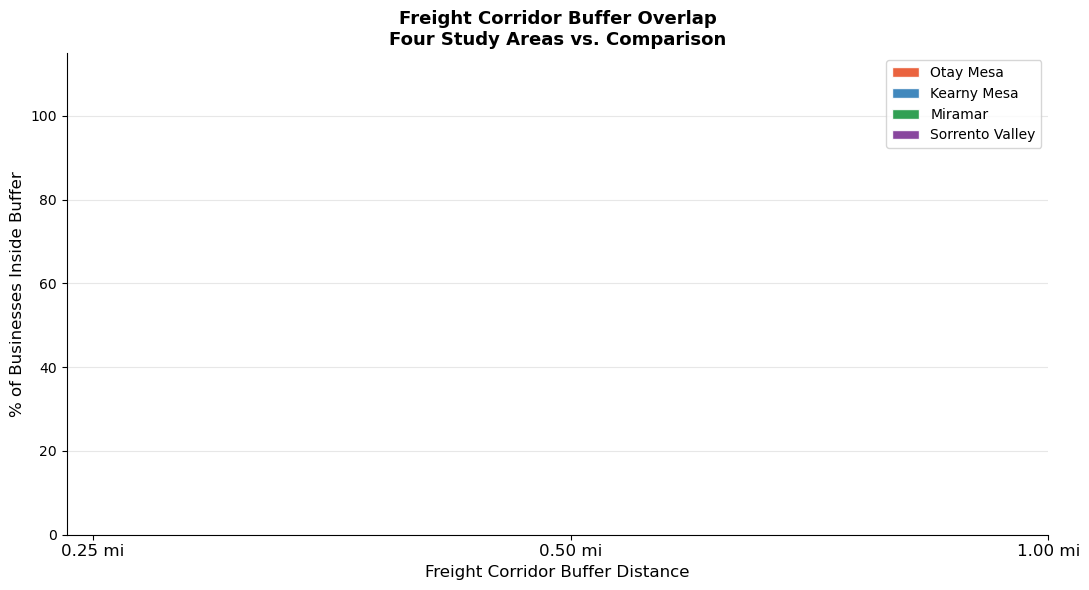

Saved: chart_buffer_comparison.png


In [12]:
x = np.arange(len(buf_labels)); width = 0.20
fig, ax = plt.subplots(figsize=(11, 6))
for i, area in enumerate(STUDY_AREAS):
    pcts = buf_pcts[area]; offset = (i - 1.5) * width
    bars = ax.bar(x + offset, pcts, width, label=area,
                  color=AREA_COLORS[area], edgecolor="white", alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8, f"{h:.1f}%",
                ha="center", va="bottom", fontsize=8,
                fontweight="bold", color=AREA_COLORS[area])
ax.set_ylabel("% of Businesses Inside Buffer", fontsize=12)
ax.set_xlabel("Freight Corridor Buffer Distance", fontsize=12)
ax.set_title("Freight Corridor Buffer Overlap\nFour Study Areas vs. Comparison",
             fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(buf_labels, fontsize=12)
ax.set_ylim(0, 115); ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("chart_buffer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_buffer_comparison.png")

## Chart — POE Distance Distribution (Box Plot, Four Areas)
**Fix:** previous versions crashed with `posx and posy should be finite values` when comparison groups had n=0.  
This cell filters to only non-empty groups before calling `ax.boxplot`.

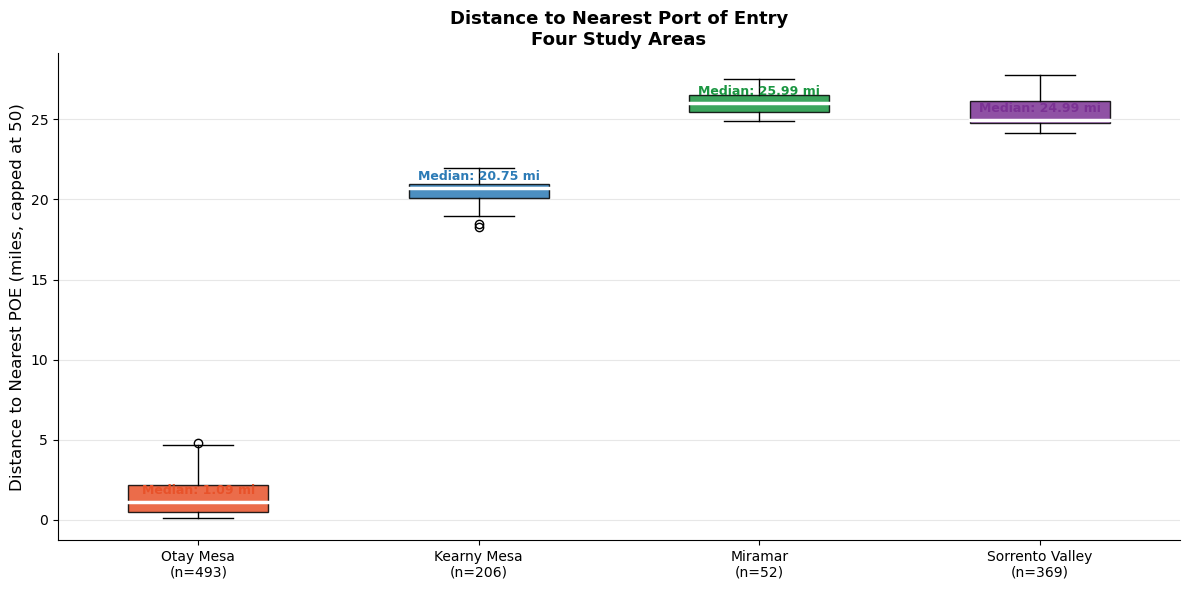

Saved: chart_poe_boxplot.png
  Otay Mesa median: 1.094 mi
  Kearny Mesa median: 20.745 mi
  Miramar median: 25.994 mi
  Sorrento Valley median: 24.992 mi


In [13]:
if "dist_nearest_poe_mi" in gdf.columns:
    data = [subarea_gdfs[a]["dist_nearest_poe_mi"].clip(upper=50).dropna().values
            for a in STUDY_AREAS]
    box_labels = [f"{a}\n(n={len(subarea_gdfs[a]):,})" for a in STUDY_AREAS]

    # FIX: only pass groups with actual data to boxplot
    valid = [(d, l, a) for d, l, a in zip(data, box_labels, STUDY_AREAS) if len(d) > 0]
    if valid:
        vdata, vlabels, vareas = zip(*valid)
        fig, ax = plt.subplots(figsize=(12, 6))
        bp = ax.boxplot(list(vdata), patch_artist=True, widths=0.5,
                        labels=list(vlabels),
                        medianprops=dict(color="white", linewidth=2.5))
        for patch, area in zip(bp["boxes"], vareas):
            patch.set_facecolor(AREA_COLORS[area]); patch.set_alpha(0.85)
        for i, (area, vals) in enumerate(zip(vareas, vdata), start=1):
            med = np.median(vals)
            ax.text(i, med + 0.5, f"Median: {med:.2f} mi",
                    ha="center", fontsize=9, color=AREA_COLORS[area],
                    fontweight="bold")
        ax.set_ylabel("Distance to Nearest POE (miles, capped at 50)", fontsize=12)
        ax.set_title("Distance to Nearest Port of Entry\nFour Study Areas",
                     fontsize=13, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig("chart_poe_boxplot.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: chart_poe_boxplot.png")
        for a in STUDY_AREAS:
            vals = subarea_gdfs[a]["dist_nearest_poe_mi"].dropna()
            print(f"  {a} median: {vals.median():.3f} mi" if len(vals) else f"  {a}: no data")
    else:
        print("No POE distance data for any area – skipping box plot.")

## Statistical Analysis — Pairwise Comparisons
Otay Mesa vs each comparison area.

- **Mann-Whitney U** on `dist_nearest_poe_mi` — continuous, non-normal → rank test. Effect size: rank-biserial *r*.
- **Chi-square + Cramér's V** on `buffer_one_mi` flag — binary outcome.

**Fix:** previous versions raised `ValueError: x and y must be of nonzero size` when `b_dist` was empty. This cell guards with `len() < 2` checks before every test.

In [14]:
try:
    from scipy.stats import mannwhitneyu, chi2_contingency

    def rank_biserial(u, n1, n2): return 1 - (2 * u) / (n1 * n2)
    def cramers_v(chi2, n, k=1):  return np.sqrt(chi2 / (n * k))
    def rb_bootstrap_ci(a, b, n_boot=2000, seed=42):
        rng = np.random.default_rng(seed); rb_boot = []
        for _ in range(n_boot):
            sa = rng.choice(a, size=len(a), replace=True)
            sb = rng.choice(b, size=len(b), replace=True)
            u, _ = mannwhitneyu(sa, sb, alternative="two-sided")
            rb_boot.append(rank_biserial(u, len(sa), len(sb)))
        return np.percentile(rb_boot, [2.5, 97.5])

    a_dist = (subarea_gdfs["Otay Mesa"]["dist_nearest_poe_mi"].dropna().values
              if "dist_nearest_poe_mi" in gdf.columns else np.array([]))
    results = []; effect_rows = []

    for comp in COMPARISON_AREAS:
        b_dist = (subarea_gdfs[comp]["dist_nearest_poe_mi"].dropna().values
                  if "dist_nearest_poe_mi" in gdf.columns else np.array([]))

        if len(a_dist) < 2 or len(b_dist) < 2:
            print(f"  {comp}: too few observations "
                  f"(Otay={len(a_dist)}, {comp}={len(b_dist)}), skipping MW.")
        else:
            u, p_mw = mannwhitneyu(a_dist, b_dist, alternative="two-sided")
            rb = rank_biserial(u, len(a_dist), len(b_dist))
            ci_lo, ci_hi = rb_bootstrap_ci(a_dist, b_dist)
            results.append({"comparison": f"Otay Mesa vs {comp}",
                            "test": "Mann-Whitney U",
                            "otay_median": round(float(np.median(a_dist)), 3),
                            "comp_median": round(float(np.median(b_dist)), 3),
                            "statistic": round(float(u), 2),
                            "p_value": float(p_mw),
                            "effect_size": round(rb, 4),
                            "effect_size_type": "Rank-biserial r",
                            "ci_lo": round(ci_lo, 4), "ci_hi": round(ci_hi, 4),
                            "significant": p_mw < 0.05})
            effect_rows.append({"label": f"POE dist\nvs {comp}",
                                 "value": rb, "lo": ci_lo, "hi": ci_hi,
                                 "type": "rank_biserial"})
            print(f"  Otay Mesa vs {comp}: U={u:.0f}, p={p_mw:.4f}, r={rb:.3f}")

        if "buffer_one_mi" in gdf.columns:
            a_buf = subarea_gdfs["Otay Mesa"]["buffer_one_mi"].dropna().astype(int)
            b_buf = subarea_gdfs[comp]["buffer_one_mi"].dropna().astype(int)
            if len(a_buf) < 2 or len(b_buf) < 2:
                print(f"  {comp}: too few buffer observations, skipping chi-sq.")
                continue
            ct = pd.crosstab(
                pd.concat([a_buf.rename("f"), b_buf.rename("f")]),
                pd.concat([pd.Series(["Otay Mesa"] * len(a_buf)),
                           pd.Series([comp] * len(b_buf))]))
            if ct.shape == (2, 2):
                chi2, p_chi, _, _ = chi2_contingency(ct)
                n_total = len(a_buf) + len(b_buf)
                cv = cramers_v(chi2, n_total)
                results.append({"comparison": f"Otay Mesa vs {comp}",
                                 "test": "Chi-square (buffer_one_mi)",
                                 "otay_median": round(100 * a_buf.mean(), 1),
                                 "comp_median": round(100 * b_buf.mean(), 1),
                                 "statistic": round(float(chi2), 2),
                                 "p_value": float(p_chi),
                                 "effect_size": round(cv, 4),
                                 "effect_size_type": "Cramér's V",
                                 "ci_lo": None, "ci_hi": None,
                                 "significant": p_chi < 0.05})
                effect_rows.append({"label": f"Buffer flag\nvs {comp}",
                                     "value": cv, "lo": None, "hi": None,
                                     "type": "cramers_v"})

    if results:
        stats_df = pd.DataFrame(results)
        stats_df.to_csv("stats_summary.csv", index=False)
        print(stats_df[["comparison", "test", "p_value",
                         "effect_size", "significant"]].to_string(index=False))
        print("\nSaved: stats_summary.csv")

except ImportError:
    print("scipy not available – skipping statistical tests.")
except Exception as ex:
    import traceback; traceback.print_exc()

  Otay Mesa vs Kearny Mesa: U=0, p=0.0000, r=1.000
  Kearny Mesa: too few buffer observations, skipping chi-sq.
  Otay Mesa vs Miramar: U=0, p=0.0000, r=1.000
  Miramar: too few buffer observations, skipping chi-sq.
  Otay Mesa vs Sorrento Valley: U=0, p=0.0000, r=1.000
  Sorrento Valley: too few buffer observations, skipping chi-sq.
                  comparison           test       p_value  effect_size  significant
    Otay Mesa vs Kearny Mesa Mann-Whitney U  1.170455e-96          1.0         True
        Otay Mesa vs Miramar Mann-Whitney U  1.733018e-32          1.0         True
Otay Mesa vs Sorrento Valley Mann-Whitney U 1.511089e-139          1.0         True

Saved: stats_summary.csv


## Chart — Effect Sizes (Mann-Whitney r + Cramér's V)
Horizontal bar chart with 95% bootstrap CIs. Vertical lines mark small / medium / large thresholds.

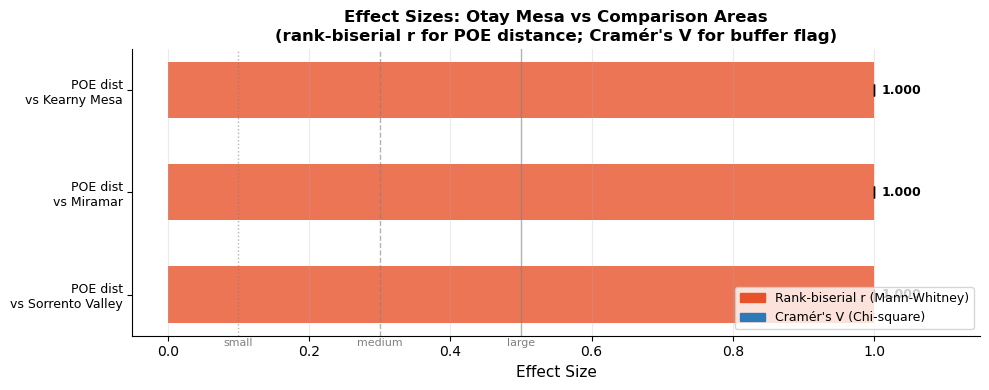

Saved: chart_effect_sizes.png

✓ All outputs complete.


In [15]:
if effect_rows:
    fig, ax = plt.subplots(figsize=(10, max(4, len(effect_rows) * 0.9 + 1)))
    colors = {"rank_biserial": "#e8522a", "cramers_v": "#2c7bb6"}
    y_pos  = range(len(effect_rows) - 1, -1, -1)
    for row, y in zip(effect_rows, y_pos):
        col = colors[row["type"]]
        ax.barh(y, row["value"], color=col, alpha=0.8, height=0.55)
        if row["lo"] is not None:
            ax.errorbar(row["value"], y,
                        xerr=[[row["value"] - row["lo"]], [row["hi"] - row["value"]]],
                        fmt="none", color="black", capsize=4, lw=1.5)
        ax.text(row["value"] + 0.01, y, f"{row['value']:.3f}",
                va="center", fontsize=9, fontweight="bold")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([r["label"] for r in reversed(effect_rows)], fontsize=9)
    ax.set_xlabel("Effect Size", fontsize=11)
    ax.set_title("Effect Sizes: Otay Mesa vs Comparison Areas\n"
                 "(rank-biserial r for POE distance; Cramér's V for buffer flag)",
                 fontsize=12, fontweight="bold")
    ax.set_xlim(-0.05, 1.15); ax.invert_yaxis()
    for thresh, label, ls in [(0.1, "small", "dotted"),
                               (0.3, "medium", "dashed"),
                               (0.5, "large", "solid")]:
        ax.axvline(thresh, color="grey", linestyle=ls, alpha=0.6, lw=1)
        ax.text(thresh, len(effect_rows) - 0.5, label, fontsize=8,
                color="grey", ha="center")
    legend_els = [
        mpatches.Patch(color=colors["rank_biserial"], label="Rank-biserial r (Mann-Whitney)"),
        mpatches.Patch(color=colors["cramers_v"],     label="Cramér's V (Chi-square)"),
    ]
    ax.legend(handles=legend_els, fontsize=9, loc="lower right", framealpha=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig("chart_effect_sizes.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: chart_effect_sizes.png")
else:
    print("No effect rows to plot (stats section may have skipped due to empty groups).")

print("\n✓ All outputs complete.")

In [17]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from shapely.geometry import Point
from io import BytesIO

# ── CRS ──────────────────────────────────────────────────────
CRS_GEO  = "EPSG:4326"
CRS_PROJ = "EPSG:3310"
METERS_PER_MILE = 1609.34

BUFFER_DISTANCES_M = {
    "buffer_quarter_mi": 402,
    "buffer_half_mi":    805,
    "buffer_one_mi":    1609,
}

# ── Load & prep businesses ────────────────────────────────────
df = pd.read_csv("industrial_businesses_core_geocoded.csv", dtype=str)
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
df = df.dropna(subset=["longitude", "latitude"]).reset_index(drop=True)

businesses = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs=CRS_GEO
).to_crs(CRS_PROJ)

# ── Assign subareas via spatial join ─────────────────────────
planning = gpd.read_file("Community_Plan_SD.geojson")
if planning.crs is None:
    planning = planning.set_crs(CRS_GEO)
planning = planning.to_crs(CRS_PROJ)

STUDY_AREA_MAP = {
    "OTAY MESA":           "Otay Mesa",
    "OTAY MESA-NESTOR":    "Otay Mesa",
    "KEARNY MESA":         "Kearny Mesa",
    "MIRAMAR RANCH NORTH": "Miramar",
    "SCRIPPS MIRAMAR RANCH": "Miramar",
    "MIRA MESA":           "Sorrento Valley",
}

sd_boundary = planning.geometry.unary_union
businesses = businesses[businesses.geometry.within(sd_boundary)].copy().reset_index(drop=True)
businesses = gpd.sjoin(
    businesses,
    planning[["CPNAME", "geometry"]],
    how="left", predicate="within"
).drop(columns=["index_right"], errors="ignore")
businesses["CPNAME"]  = businesses["CPNAME"].fillna("Outside City Planning Areas")
businesses["subarea"] = businesses["CPNAME"].map(STUDY_AREA_MAP).fillna("Other")

# ── Load freight roads ────────────────────────────────────────
major_roads = gpd.read_file(
    BytesIO(requests.get(
        "https://gis.sandag.org/FreightViewer/data/MajorRoads_20171002.json",
        timeout=60
    ).content)
).to_crs(CRS_PROJ)

roads_dissolved = major_roads.dissolve().geometry.iloc[0]

print(f"Businesses loaded: {len(businesses)}")
print(f"Otay Mesa businesses: {len(businesses[businesses['subarea'] == 'Otay Mesa'])}")
print("Ready — run the map cell below.")

Businesses loaded: 2500
Otay Mesa businesses: 493
Ready — run the map cell below.


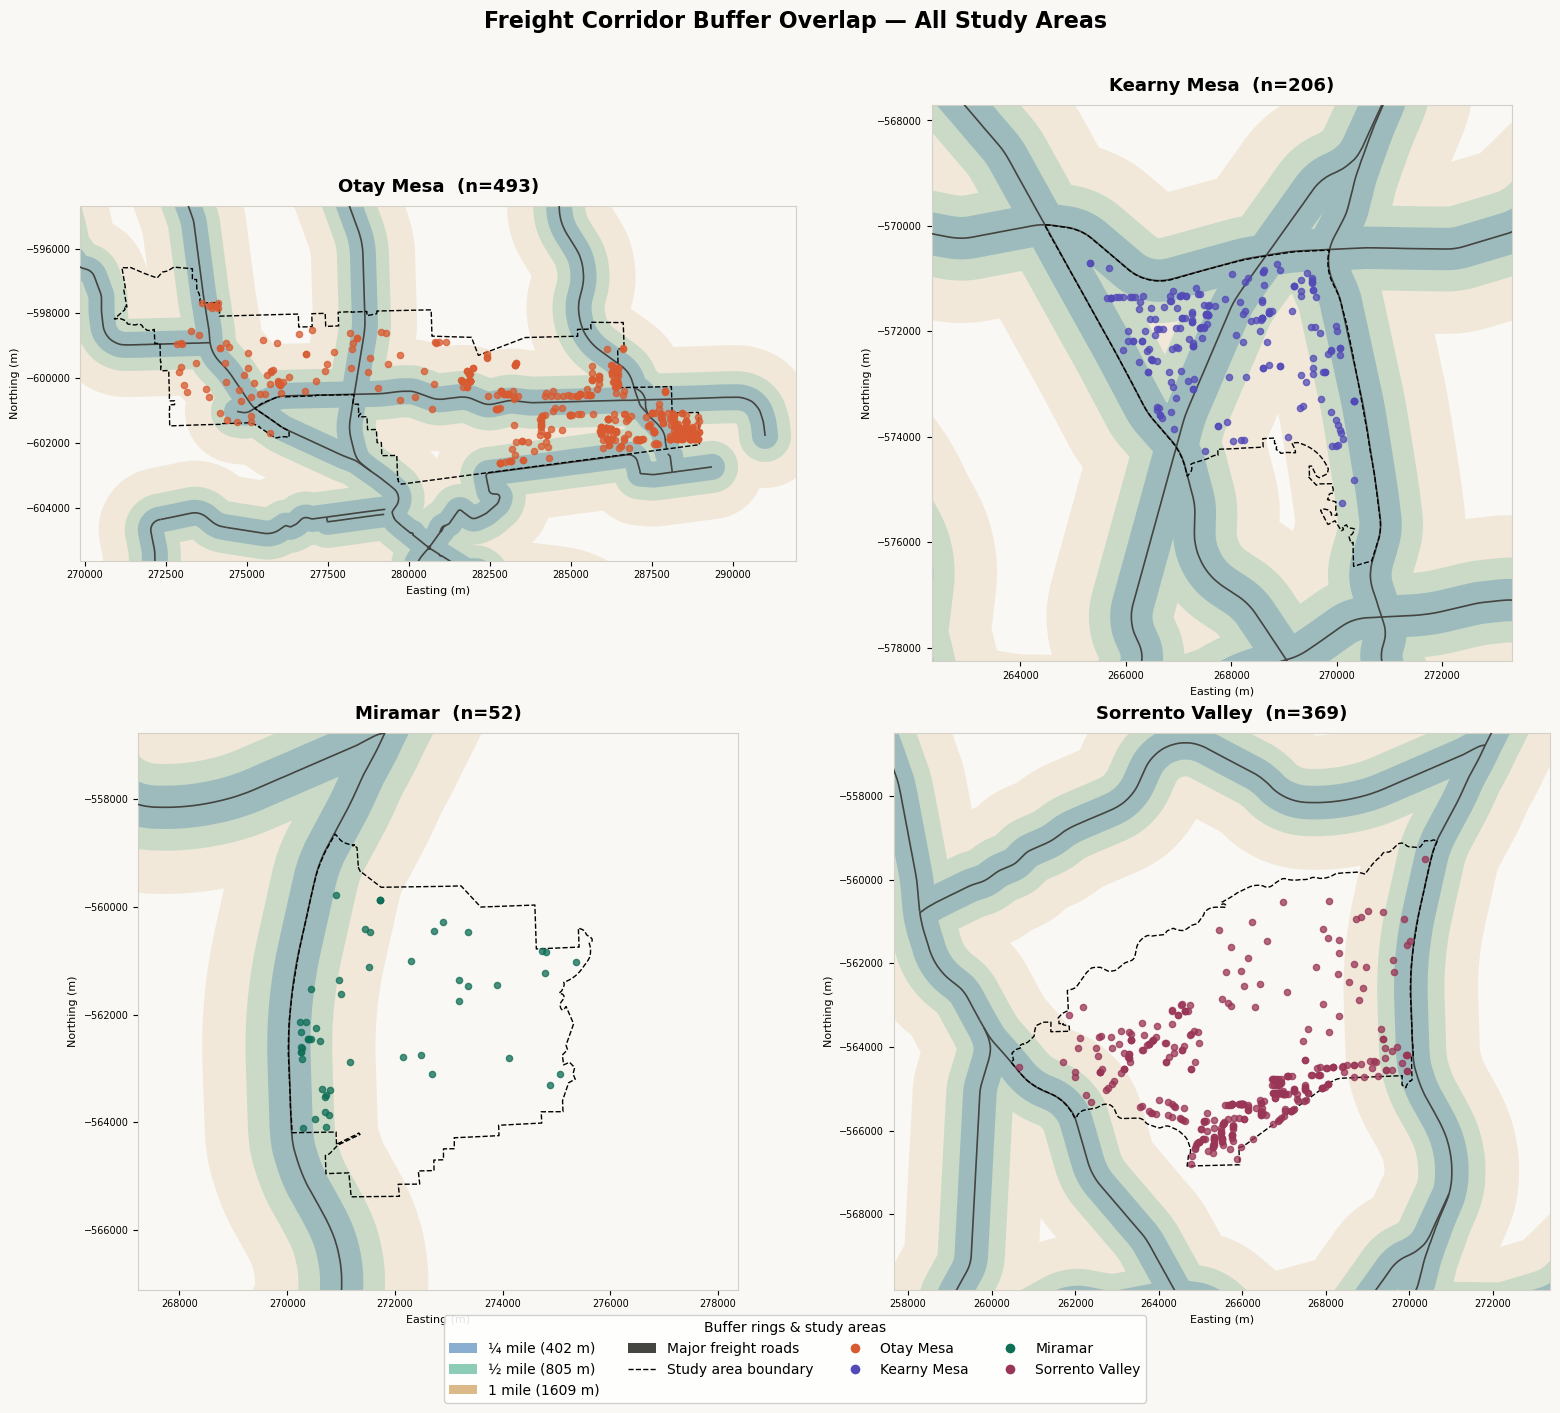

In [20]:
# ── Parameters ──────────────────────────────────────────────
BUFFER_COLORS  = ["#185FA5", "#1D9E75", "#BA7517"]
BUFFER_LABELS  = ["¼ mile (402 m)", "½ mile (805 m)", "1 mile (1609 m)"]
BUFFER_ALPHAS  = [0.25, 0.18, 0.12]

SUBAREA_COLORS = {
    "Otay Mesa":      "#D85A30",
    "Kearny Mesa":    "#534AB7",
    "Miramar":        "#0F6E56",
    "Sorrento Valley":"#993556",
}

ROAD_COLOR  = "#444441"
BACKGROUND  = "#F9F8F4"

STUDY_AREAS = ["Otay Mesa", "Kearny Mesa", "Miramar", "Sorrento Valley"]

# ── 2x2 Facet map ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor=BACKGROUND)
axes = axes.flatten()

for ax, subarea in zip(axes, STUDY_AREAS):
    ax.set_facecolor(BACKGROUND)

    subset = businesses[businesses["subarea"] == subarea].copy()

    # Buffers: largest first
    for dist_m, color, alpha in zip(
        reversed(list(BUFFER_DISTANCES_M.values())),
        reversed(BUFFER_COLORS),
        reversed(BUFFER_ALPHAS),
    ):
        buf = gpd.GeoDataFrame(geometry=[roads_dissolved.buffer(dist_m)], crs=CRS_PROJ)
        buf.plot(ax=ax, color=color, alpha=alpha, zorder=2)

    # Freight road centreline
    gpd.GeoDataFrame(geometry=[roads_dissolved], crs=CRS_PROJ).plot(
        ax=ax, color=ROAD_COLOR, linewidth=1.2, zorder=3
    )

    # ── Study area boundary ──────────────────────────────────
    # Dissolve all planning districts that map to this subarea
    subarea_boundary = (
        planning[planning["CPNAME"].map(STUDY_AREA_MAP).fillna("Other") == subarea]
        .dissolve()
        .to_crs(CRS_PROJ)
    )
    subarea_boundary.boundary.plot(
        ax=ax, color="black", linewidth=1.0, linestyle="--", zorder=5
    )

    # Business points
    subset.plot(
        ax=ax,
        color=SUBAREA_COLORS[subarea],
        markersize=20,
        alpha=0.75,
        zorder=6,
        marker="o",
    )

    # Zoom to subarea extent + padding
    if len(subset) > 0:
        bounds = subset.total_bounds
        pad = 3000
        ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
        ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

    ax.set_title(f"{subarea}  (n={len(subset)})", fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Easting (m)", fontsize=8)
    ax.set_ylabel("Northing (m)", fontsize=8)
    ax.tick_params(labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#D3D1C7")

# ── Shared legend ────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=c, alpha=0.5, label=l)
    for c, l in zip(BUFFER_COLORS, BUFFER_LABELS)
] + [
    mpatches.Patch(facecolor=ROAD_COLOR, label="Major freight roads"),
    plt.Line2D([0], [0], color="black", linewidth=1.0,
               linestyle="--", label="Study area boundary"),
] + [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=SUBAREA_COLORS[sa],
               markersize=8, label=sa)
    for sa in STUDY_AREAS
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=4,
    frameon=True,
    framealpha=0.9,
    fontsize=10,
    title="Buffer rings & study areas",
    title_fontsize=10,
    bbox_to_anchor=(0.5, 0.01),
)

fig.suptitle("Freight Corridor Buffer Overlap — All Study Areas",
             fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("all_subareas_bullseye_buffer_map.png", dpi=150, bbox_inches="tight")
plt.show()